In [1]:
import pandas as pd
import os
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn import metrics
import plotly.express as px
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Constants

In [2]:
str_project = os.getcwd().split('\\')[4]
print(f'Project: {str_project}')
str_task = os.getcwd().split('\\')[5]
print(f'Task: {str_task}')
str_subtask = os.getcwd().split('\\')[6]
print(f'Subtask: {str_subtask}')

str_dirname_output = './output'

Project: 06_ml_in_python
Task: 03_homecredit_default_risk_model
Subtask: 04_model_building


In [3]:
os.getcwd()

'M:\\Risk Management\\Bridger Hyde\\20240521_bridger_internship\\06_ml_in_python\\03_homecredit_default_risk_model\\04_model_building'

In [33]:
try:
    os.mkdir(str_dirname_output)
except FileExistsError:
    pass

# Pull In Datasets

In [4]:
dftrainset = pd.read_csv('M:\\Risk Management\\Bridger Hyde\\20240521_bridger_internship\\06_ml_in_python\\03_homecredit_default_risk_model\\01_data_collection\\output\\dftrain.csv')
dftestset = pd.read_csv('M:\\Risk Management\\Bridger Hyde\\20240521_bridger_internship\\06_ml_in_python\\03_homecredit_default_risk_model\\01_data_collection\\output\\dftest.csv')

In [15]:
# search the dataframes for columns that are missing values and show it as a %
missing = dftrainset.isnull().mean() * 100
print(missing[missing > 0])
# removes columns that are missing over 65 % of values (changes to 75%)
cols_to_remove = missing[missing > 75].index
print(cols_to_remove)
# drop columns 
df_train_clean = dftrainset.drop(columns=cols_to_remove)
df_train_clean.shape

AMT_ANNUITY_x          0.005820
AMT_GOODS_PRICE        0.039795
NAME_TYPE_SUITE        0.309558
OWN_CAR_AGE           63.854655
OCCUPATION_TYPE       31.025386
                        ...    
CREDIT_TYPE           29.139342
DAYS_CREDIT_UPDATE    29.139342
AMT_ANNUITY_y         54.654539
MONTHS_BALANCE        29.139342
STATUS                29.139342
Length: 85, dtype: float64
Index(['AMT_CREDIT_MAX_OVERDUE'], dtype='object')


(738795, 139)

In [16]:
# Duplicate column drop on test set
df_test_clean = dftestset.drop(columns=cols_to_remove)
# show shape of dataset (has 1 less columns due to missing target col)
df_test_clean.shape


(257272, 138)

In [17]:
# setting numerical columns and categorical columns to variables
numcolstrain = df_train_clean.select_dtypes(include=['float64','int64']).columns
catcolstrain = df_train_clean.select_dtypes(include=['object']).columns

numcolstest = df_test_clean.select_dtypes(include=['float64','int64']).columns
catcolstest = df_test_clean.select_dtypes(include=['object']).columns

# filling missing values with 0 and unknown (future imputing done at a later time MODE was best results)
#df_train_clean[numcolstrain] = df_train_clean[numcolstrain].fillna(df_train_clean[numcolstrain].mean())
df_train_clean[numcolstrain] = df_train_clean[numcolstrain].fillna(0)
df_train_clean[catcolstrain] = df_train_clean[catcolstrain].fillna('Unknown')

#df_test_clean[numcolstest] = df_test_clean[numcolstest].fillna(df_test_clean[numcolstest].mean())
df_test_clean[numcolstest] = df_test_clean[numcolstest].fillna(0)
df_test_clean[catcolstest] = df_test_clean[catcolstest].fillna('Unknown')

In [18]:
dftrainset = df_train_clean
dftestset = df_test_clean

In [19]:
categorical_cols = dftrainset.select_dtypes(include=['object', 'category']).columns.tolist()
print(categorical_cols)

['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE', 'CREDIT_ACTIVE', 'CREDIT_CURRENCY', 'CREDIT_TYPE', 'STATUS']


In [20]:
# seperate features and target
X = dftrainset.drop('TARGET', axis=1)
y = dftrainset['TARGET']

In [21]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
X_test = dftestset

In [23]:
# new model test
model = CatBoostClassifier(
    iterations = 1156,
    learning_rate = 0.06,
    depth = 4,
    verbose = 50,
    l2_leaf_reg=4,
    border_count=256,
    early_stopping_rounds=100
)

In [24]:
# set up training pools
train_pool = Pool(data=X_train, label=y_train, cat_features=categorical_cols)
valid_pool = Pool(data=X_valid, label=y_valid, cat_features=categorical_cols)
test_pool = Pool(data=X_test, cat_features=categorical_cols)

In [25]:
# fit the model to the data
model.fit(
    train_pool,
    eval_set=valid_pool,
    use_best_model=True
)

0:	learn: 0.6316968	test: 0.6314392	best: 0.6314392 (0)	total: 1.37s	remaining: 26m 19s
50:	learn: 0.2596379	test: 0.2552116	best: 0.2552116 (50)	total: 45s	remaining: 16m 14s
100:	learn: 0.2513544	test: 0.2464192	best: 0.2464192 (100)	total: 1m 28s	remaining: 15m 21s
150:	learn: 0.2476483	test: 0.2425452	best: 0.2425452 (150)	total: 2m 6s	remaining: 14m 2s
200:	learn: 0.2456928	test: 0.2407715	best: 0.2407715 (200)	total: 2m 43s	remaining: 12m 59s
250:	learn: 0.2437376	test: 0.2389192	best: 0.2389192 (250)	total: 3m 22s	remaining: 12m 8s
300:	learn: 0.2420205	test: 0.2372864	best: 0.2372864 (300)	total: 3m 58s	remaining: 11m 16s
350:	learn: 0.2402924	test: 0.2355829	best: 0.2355829 (350)	total: 4m 35s	remaining: 10m 32s
400:	learn: 0.2389869	test: 0.2343476	best: 0.2343476 (400)	total: 5m 13s	remaining: 9m 50s
450:	learn: 0.2377998	test: 0.2332765	best: 0.2332765 (450)	total: 5m 51s	remaining: 9m 9s
500:	learn: 0.2362210	test: 0.2316788	best: 0.2316788 (500)	total: 6m 28s	remaining: 8

In [26]:
y_valid_pred = model.predict(valid_pool)

# get validation accuracy score
valid_accuracy = accuracy_score(y_valid, y_valid_pred)
print("Validation Accuracy: ", valid_accuracy)

Validation Accuracy:  0.9255341468201599


In [27]:
# prints classification report
print(classification_report(y_valid, y_valid_pred))

# prints y test predictions
y_test_pred = model.predict(X_test)
print("y test pred:", y_test_pred)

# prints y test prediction probabilities
y_test_pred_prob = model.predict_proba(X_test)
print(y_test_pred_prob)

# gather valid prediction probability for graph
y_valid_pred_prob = model.predict_proba(X_valid)[:, 1]

              precision    recall  f1-score   support

           0       0.93      1.00      0.96    135848
           1       0.86      0.09      0.17     11911

    accuracy                           0.93    147759
   macro avg       0.89      0.55      0.56    147759
weighted avg       0.92      0.93      0.90    147759

y test pred: [0 0 0 ... 0 0 0]
[[0.95074164 0.04925836]
 [0.95031574 0.04968426]
 [0.95074164 0.04925836]
 ...
 [0.82964536 0.17035464]
 [0.79774054 0.20225946]
 [0.84218037 0.15781963]]


In [28]:
y_score = model.predict_proba(X_test)[:, 1]
print(y_score)

[0.04925836 0.04968426 0.04925836 ... 0.17035464 0.20225946 0.15781963]


In [29]:
fpr, tpr, _ = roc_curve(y_valid, y_valid_pred_prob)
roc_auc = auc(fpr, tpr)

In [30]:
metrics.auc(fpr,tpr)

0.8266503536764838

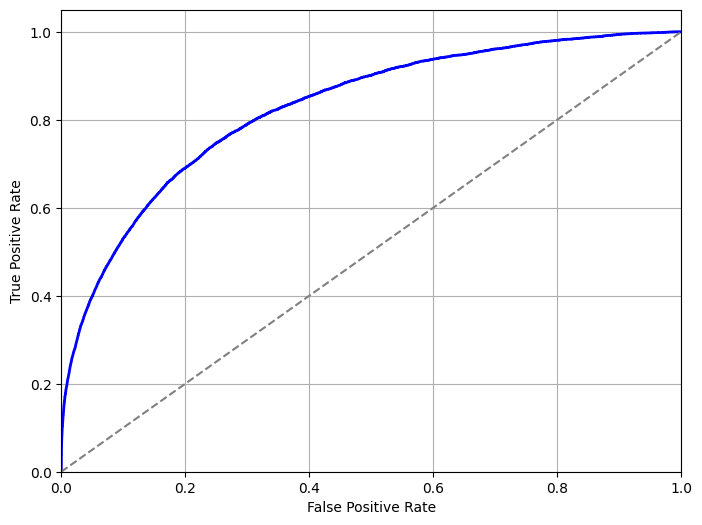

In [31]:
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid()
plt.show()

In [32]:
testids = dftestset['SK_ID_CURR']
print(testids)

0         100001
1         100001
2         100001
3         100001
4         100001
           ...  
257267    456224
257268    456224
257269    456250
257270    456250
257271    456250
Name: SK_ID_CURR, Length: 257272, dtype: int64


In [34]:
dfsubmission = pd.DataFrame({
    'SK_ID_CURR' : testids,
    'TARGET' : y_score
})

dfsubmission

,SK_ID_CURR,TARGET
0,100001,0.049258
1,100001,0.049684
2,100001,0.049258
3,100001,0.048564
4,100001,0.070289
...,...,...
257267,456224,0.025763
257268,456224,0.027540
257269,456250,0.170355
257270,456250,0.202259


In [40]:
mean_df = dfsubmission.groupby('SK_ID_CURR')['TARGET'].mean().reset_index()
mean_df

,SK_ID_CURR,TARGET
0,100001,0.056261
1,100005,0.172787
2,100013,0.012109
3,100028,0.037411
4,100038,0.139260
...,...,...
48739,456221,0.040176
48740,456222,0.059178
48741,456223,0.040742
48742,456224,0.027558


In [38]:
firstrow = dfsubmission.drop_duplicates(subset='SK_ID_CURR', keep='first')

print(firstrow)

        SK_ID_CURR    TARGET
0           100001  0.049258
7           100005  0.152340
10          100013  0.011076
14          100028  0.035863
26          100038  0.139260
...            ...       ...
257241      456221  0.033509
257246      456222  0.059178
257247      456223  0.039221
257252      456224  0.032712
257269      456250  0.170355

[48744 rows x 2 columns]


In [41]:
mean_df.to_csv('./output/submission.csv', index=False)